**1. A Gaussian integral**

Using Monte Carlo integration, check that

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks *very* accurate! And if $N$ is small?)
- How does the distribution change if $N$ increases?

(Hint: think about sample mean and sample variance)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import poisson

# Consistent, publication-quality plot style
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "text.usetex": False,   # explicitly disable LaTeX rendering
    "figure.figsize": (6, 4),
    "figure.dpi": 100
})

%config InlineBackend.figure_format = 'retina'

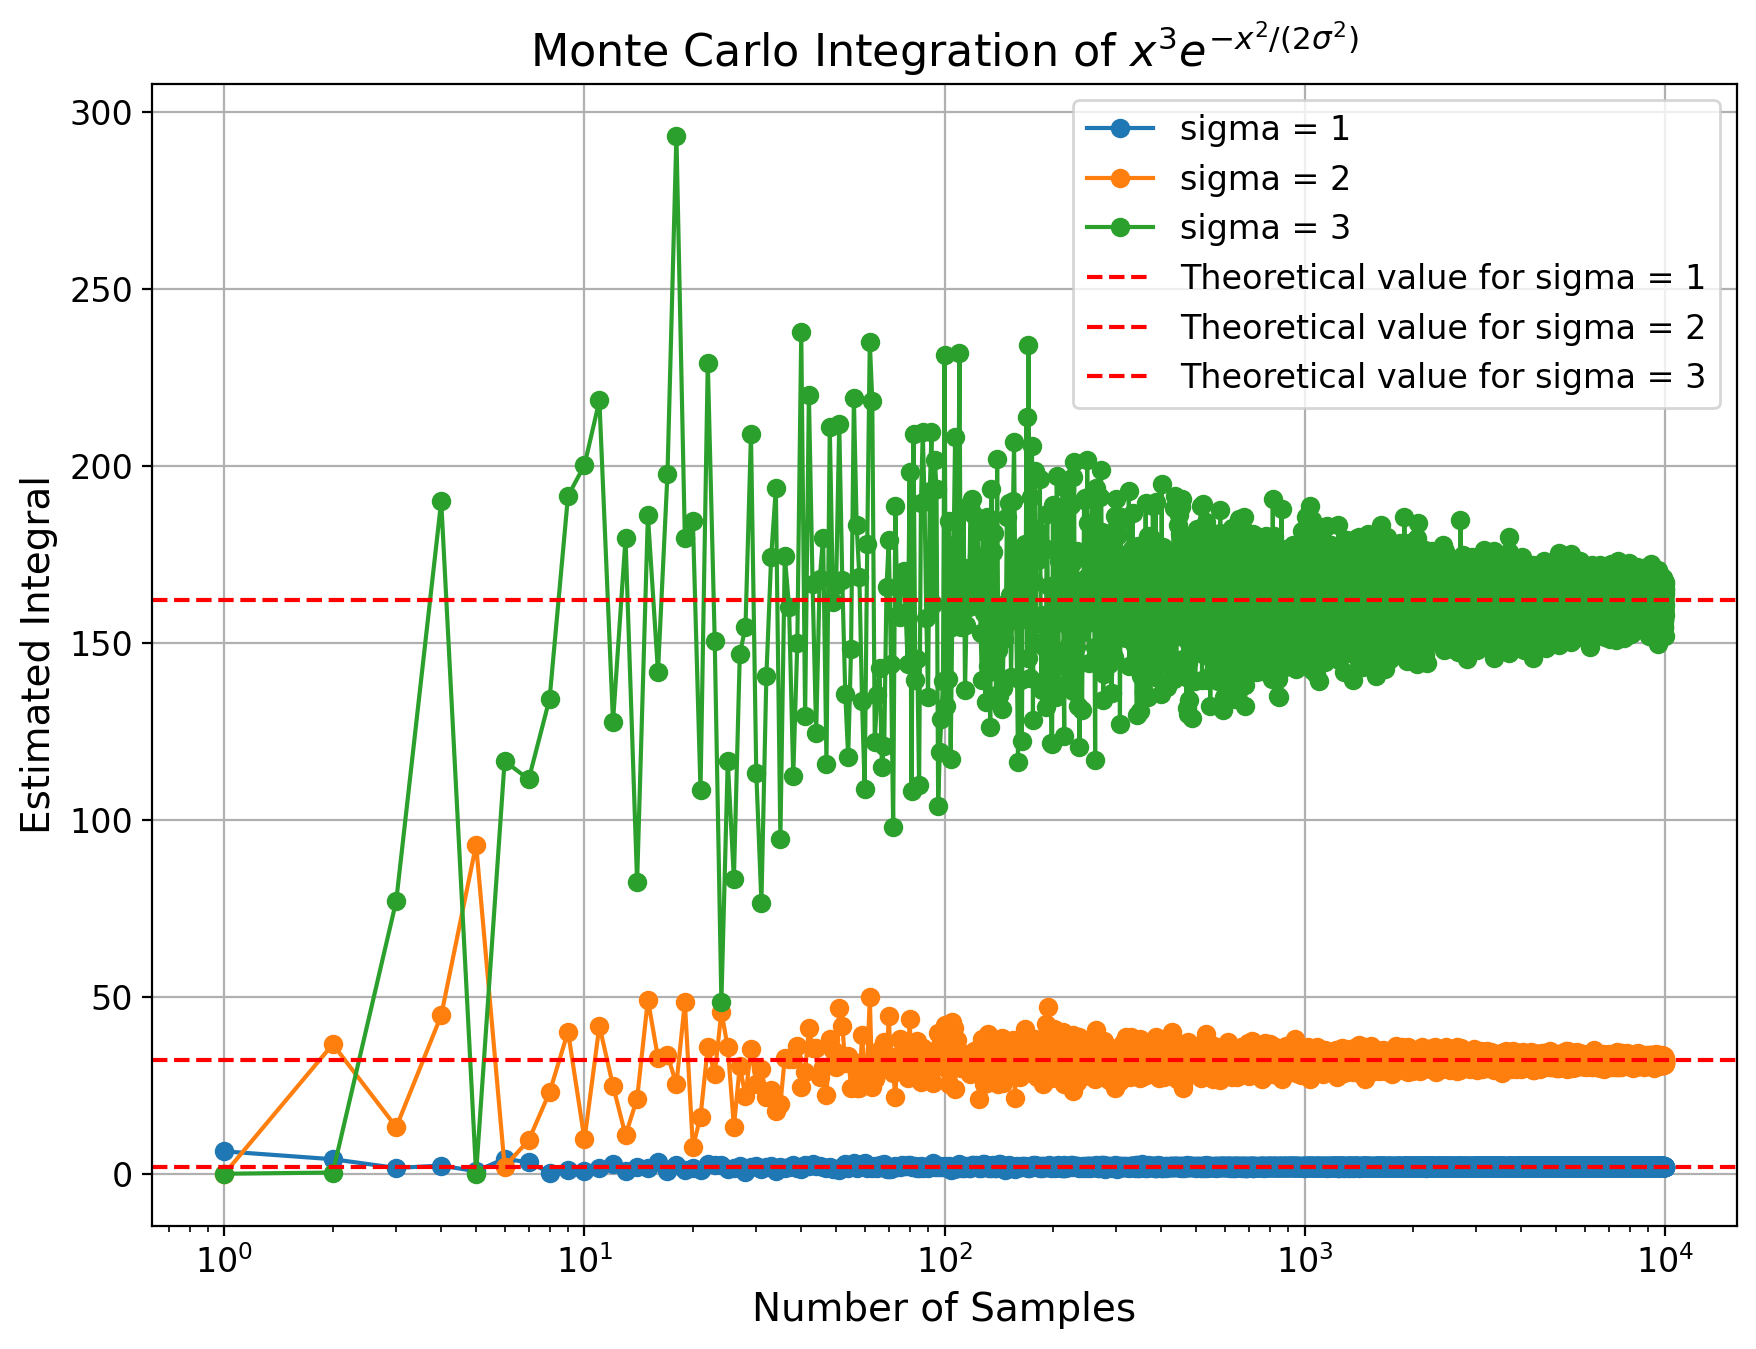

In [12]:
# Define the function to integrate
def f(x, sigma):
    return x**3 * np.exp(-x**2 / (2 * sigma**2))

# Monte Carlo integration function
def monte_carlo_integration(sigma, num_samples):
    # Generate random samples from a uniform distribution
    samples = np.random.uniform(0, 10 * sigma, num_samples)  # Limit to a reasonable range
    # Calculate the function values at the sampled points
    function_values = f(samples, sigma)
    # Estimate the integral
    integral_estimate = (10 * sigma) * np.mean(function_values)  # Scale by the range
    return integral_estimate

# Parameters
sigmas = [1, 2, 3]  # Different values of sigma
num_samples_list = np.arange(1, 10000)  # Different sample sizes
# Initialize a dictionary to store results for each sigma value
# Keys are sigma values, values are lists to accumulate integral estimates
results = {sigma: [] for sigma in sigmas}

# Perform Monte Carlo integration for each sigma and sample size
for sigma in sigmas:
    for num_samples in num_samples_list:
        integral_estimate = monte_carlo_integration(sigma, num_samples)
        results[sigma].append(integral_estimate)

# Plotting the results
plt.figure(figsize=(9, 7))
for sigma in sigmas:
    plt.plot(num_samples_list, results[sigma], marker='o', label=f'sigma = {sigma}')

# Theoretical value
theoretical_values = [2 * sigma**4 for sigma in sigmas]
for i, sigma in enumerate(sigmas):
    plt.axhline(y=theoretical_values[i], color='r', linestyle='--', label=f'Theoretical value for sigma = {sigma}')

plt.xscale('log')
plt.xlabel('Number of Samples')
plt.ylabel('Estimated Integral')
plt.title(r'Monte Carlo Integration of $x^3 e^{-x^2/(2\sigma^2)}$')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

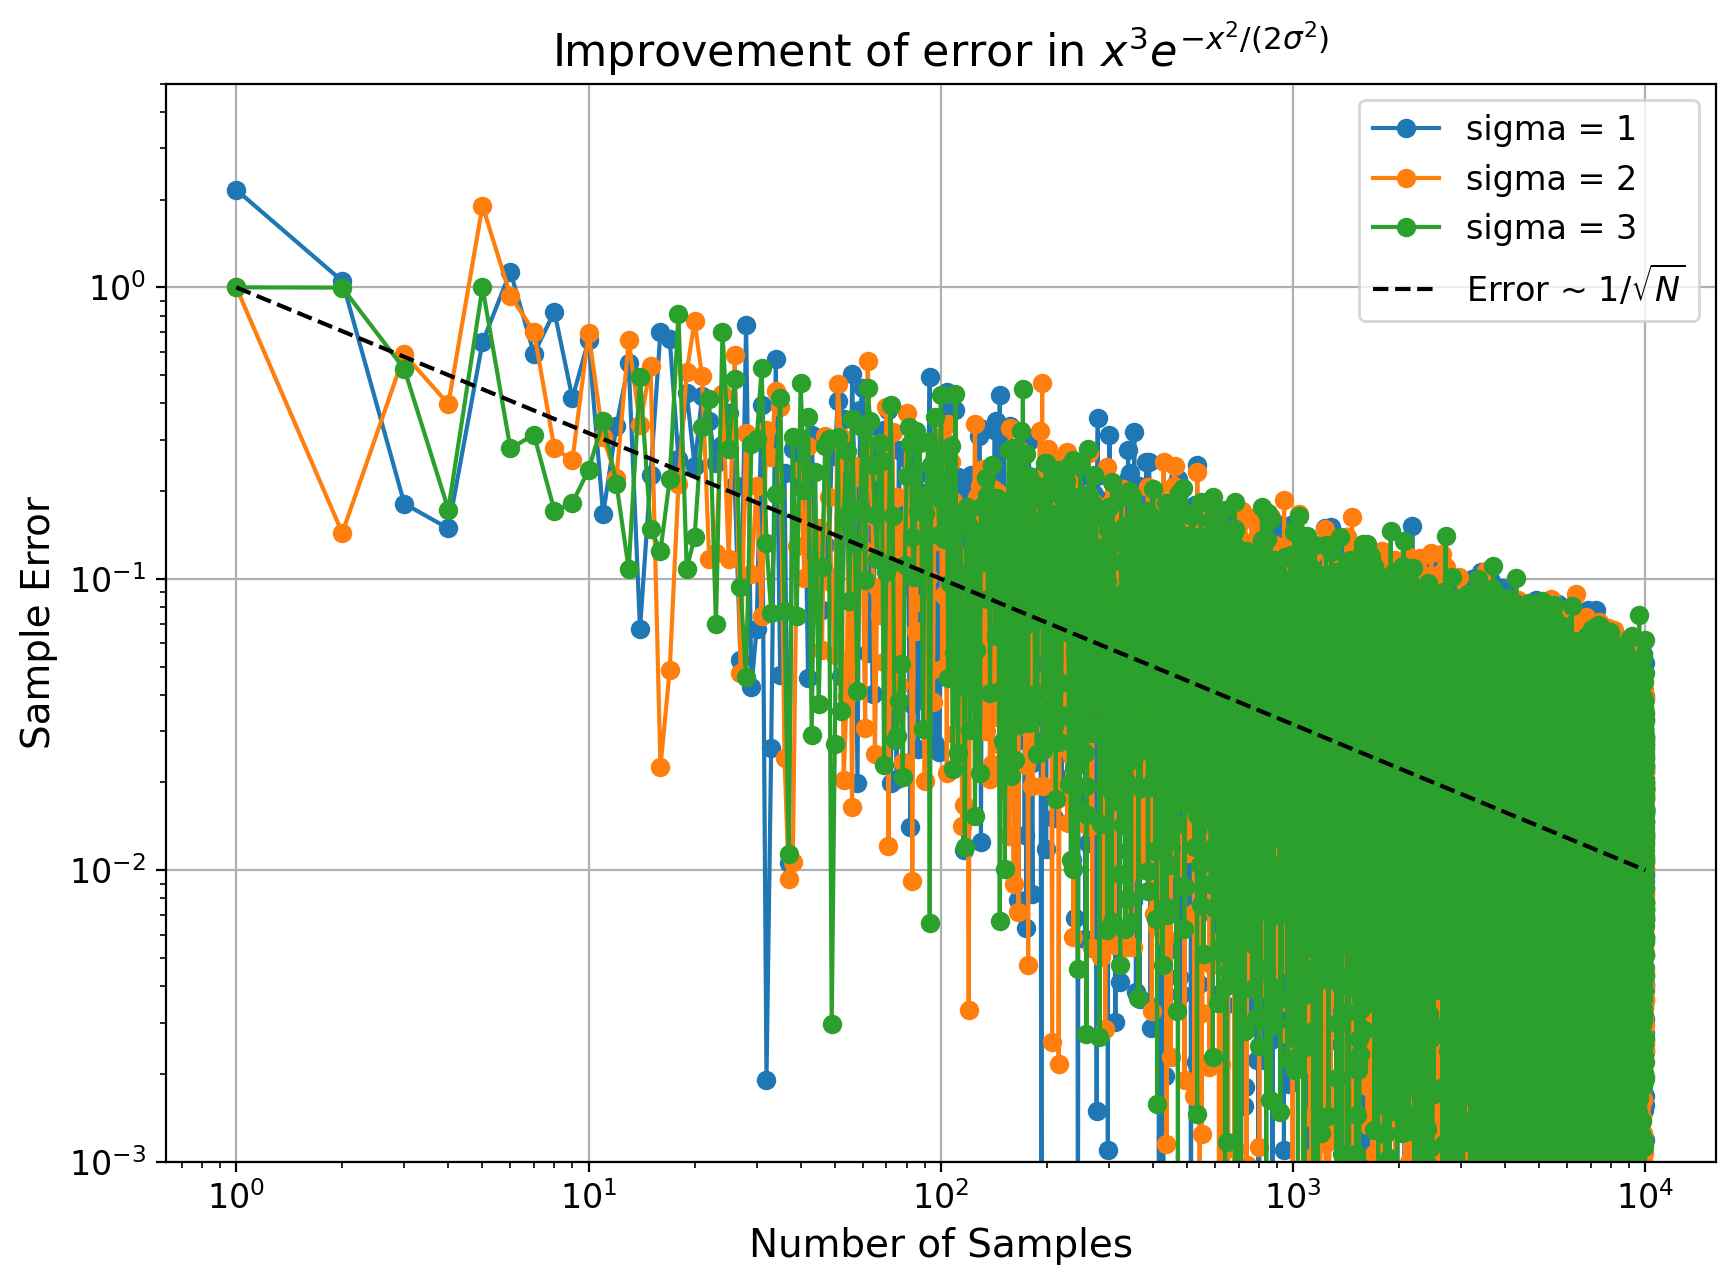

In [13]:
# How does the error improve with number of samples?
# Plotting the results
plt.figure(figsize=(10, 7))
theoretical_values = [2 * sigma**4 for sigma in sigmas]  # Correctly define theoretical values
for sigma in sigmas:
    plt.plot(num_samples_list, abs((np.array(results[sigma]) - theoretical_values[sigmas.index(sigma)]) / theoretical_values[sigmas.index(sigma)]), marker='o', label=f'sigma = {sigma}')
plt.plot(num_samples_list, (num_samples_list)**-0.5, linestyle='--', label=r'Error ~ $1/\sqrt{N}$', color='black')
plt.xscale('log')
plt.xlabel('Number of Samples')
plt.ylabel('Sample Error')
plt.title(r'Improvement of error in $x^3 e^{-x^2/(2\sigma^2)}$')
plt.legend()
plt.grid()
plt.ylim(10**(-3), 5)
plt.loglog()
plt.show()

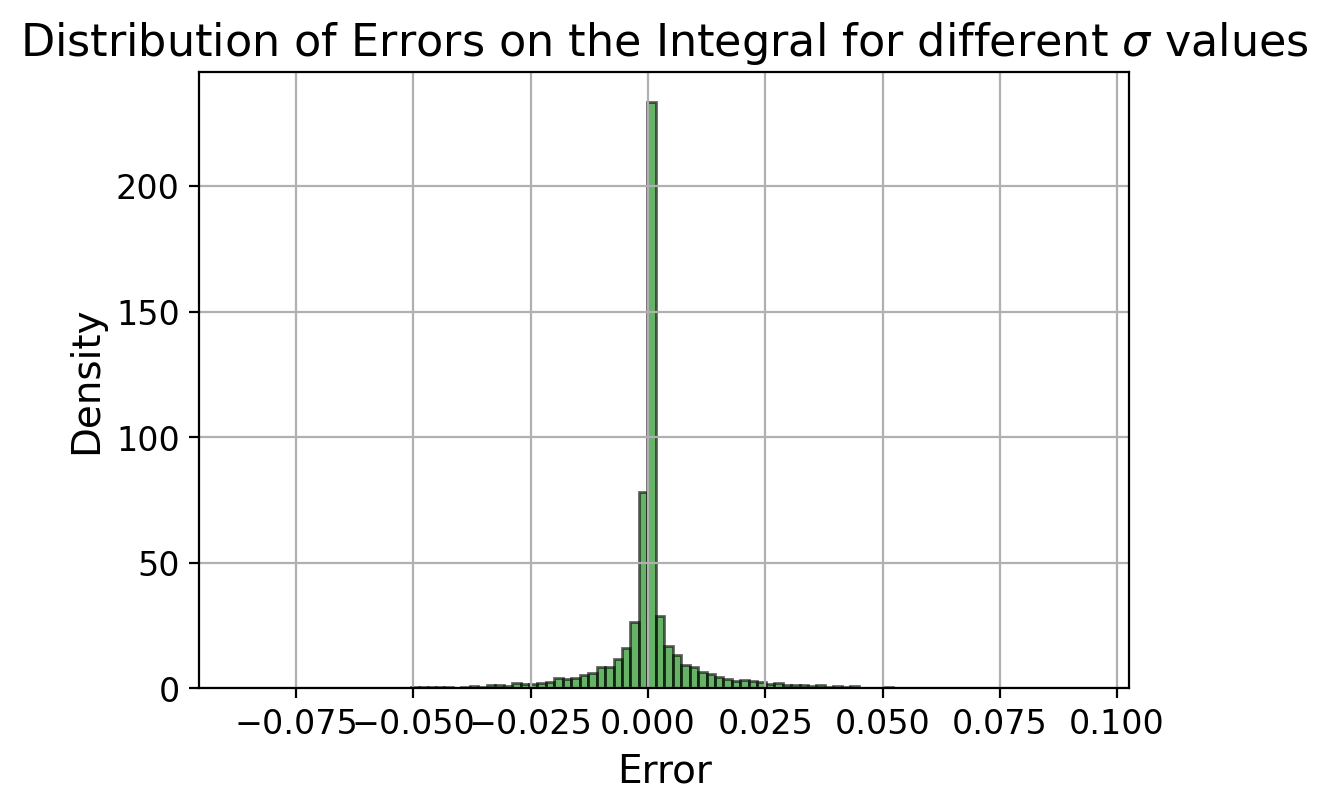

In [14]:
# Now let's look at the distribution of errors for different sigma values (not identically distributed)
sigmas = np.linspace(0.01, 1, 10000)  # Different values of sigma
# num_samples_list = [10, 100, 1000, 10000, 100000]  # Different sample sizes
errors = []
# Perform Monte Carlo integration for each sigma and sample size
for sigma in sigmas:
    integral_estimate = monte_carlo_integration(sigma, 10000)
    theoretical_value = 2 * sigma**4
    error = integral_estimate - theoretical_value
    errors.append(error)

# Convert errors to numpy array 
errors = np.array(errors)

# Plot the distribution of errors
plt.figure(figsize=(6, 4))
plt.hist(errors, bins=100, density=True, alpha=0.6, color='g', edgecolor='black')
plt.title(r'Distribution of Errors on the Integral for different $\sigma$ values')
plt.xlabel('Error')
plt.ylabel('Density')
plt.grid()
plt.show()

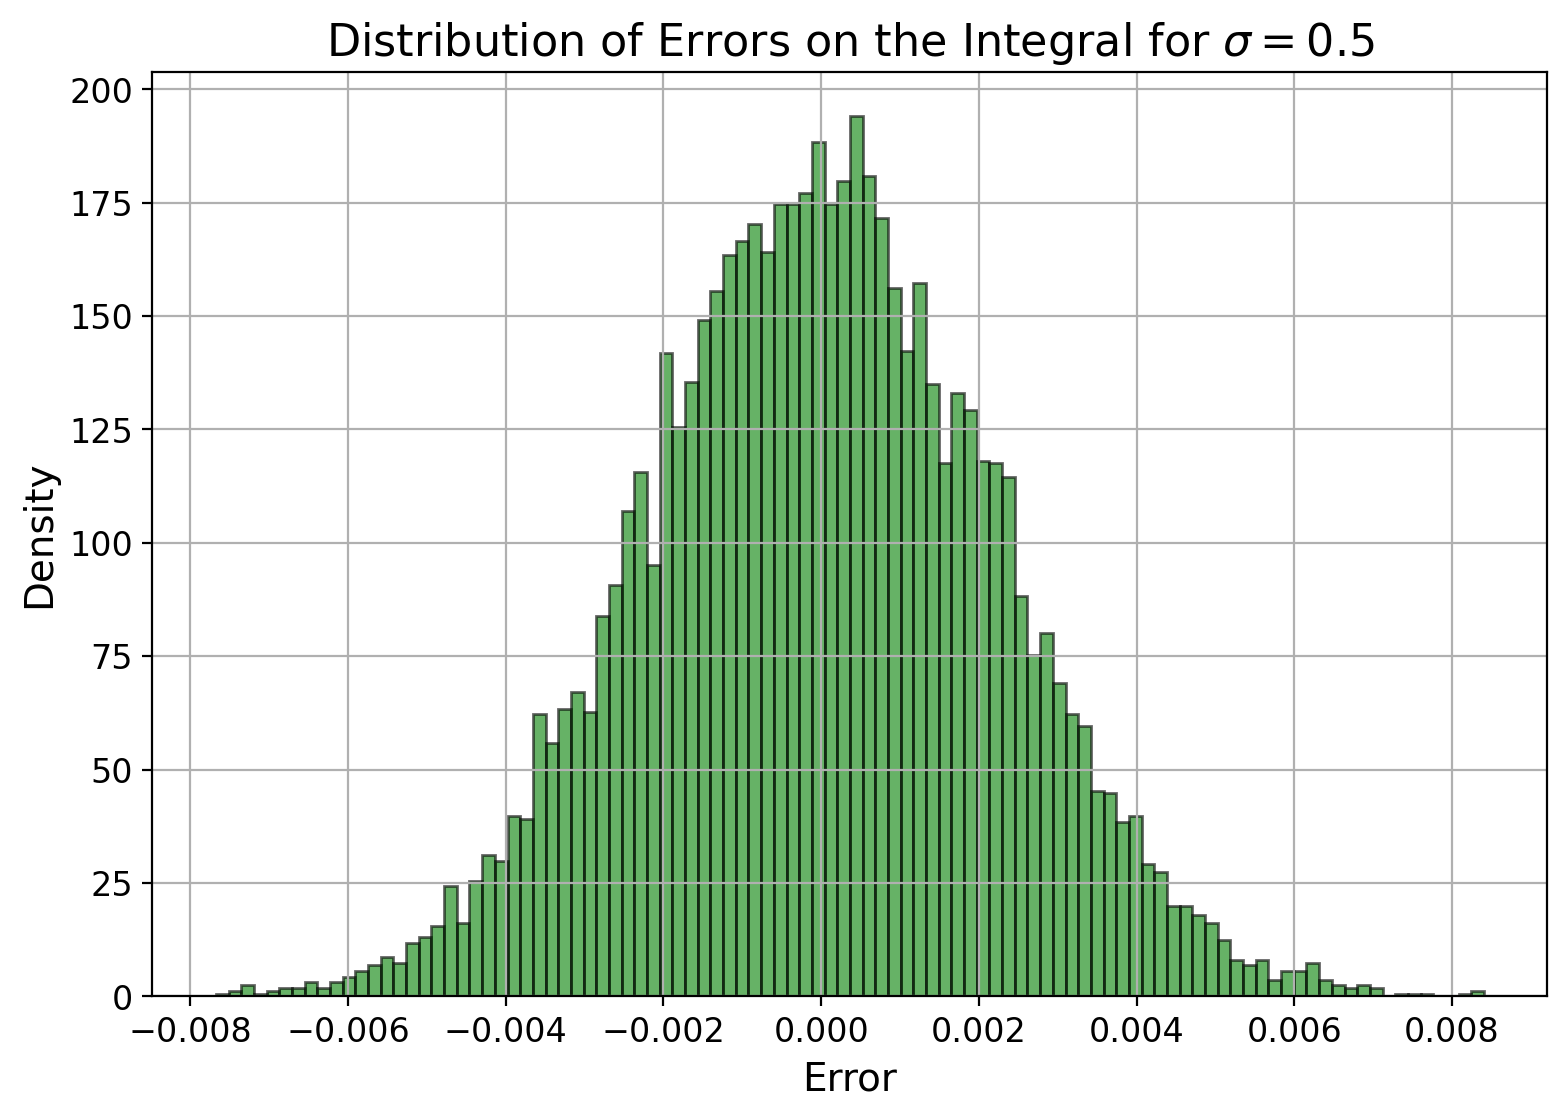

In [15]:
# Now we want to show not the distributions of the error for the same sigma, but the different errors for running the monte carlo with a fixed sigma multiple times. So what is the sample error distribution for a fixed sigma?
# Parameters
sigma = 0.5  # Fixed value of sigma
num_runs = 10000  # Number of Monte Carlo runs
errors = []

# Perform Monte Carlo integration multiple times
for _ in range(num_runs):
    integral_estimate = monte_carlo_integration(sigma, 10000) # Fixed number of draws from the distribution, N = 10000
    theoretical_value = 2 * sigma**4
    error = integral_estimate - theoretical_value # Calculate the error for this run
    errors.append(error) # Append the error to the list of errors

# Convert errors to numpy array
errors = np.array(errors) 

# Plot the distribution of errors
plt.figure(figsize=(9, 6))
plt.hist(errors, bins=100, density=True, alpha=0.6, color='g', edgecolor='black')
plt.title(r'Distribution of Errors on the Integral for $\sigma = {}$'.format(sigma))
plt.xlabel('Error')
plt.ylabel('Density')
plt.grid()
plt.show()

Mean error: -1.591440e-05
Std error: 2.212968e-03
Theoretical std (sigma^2/sqrt(N)): 2.500000e-03


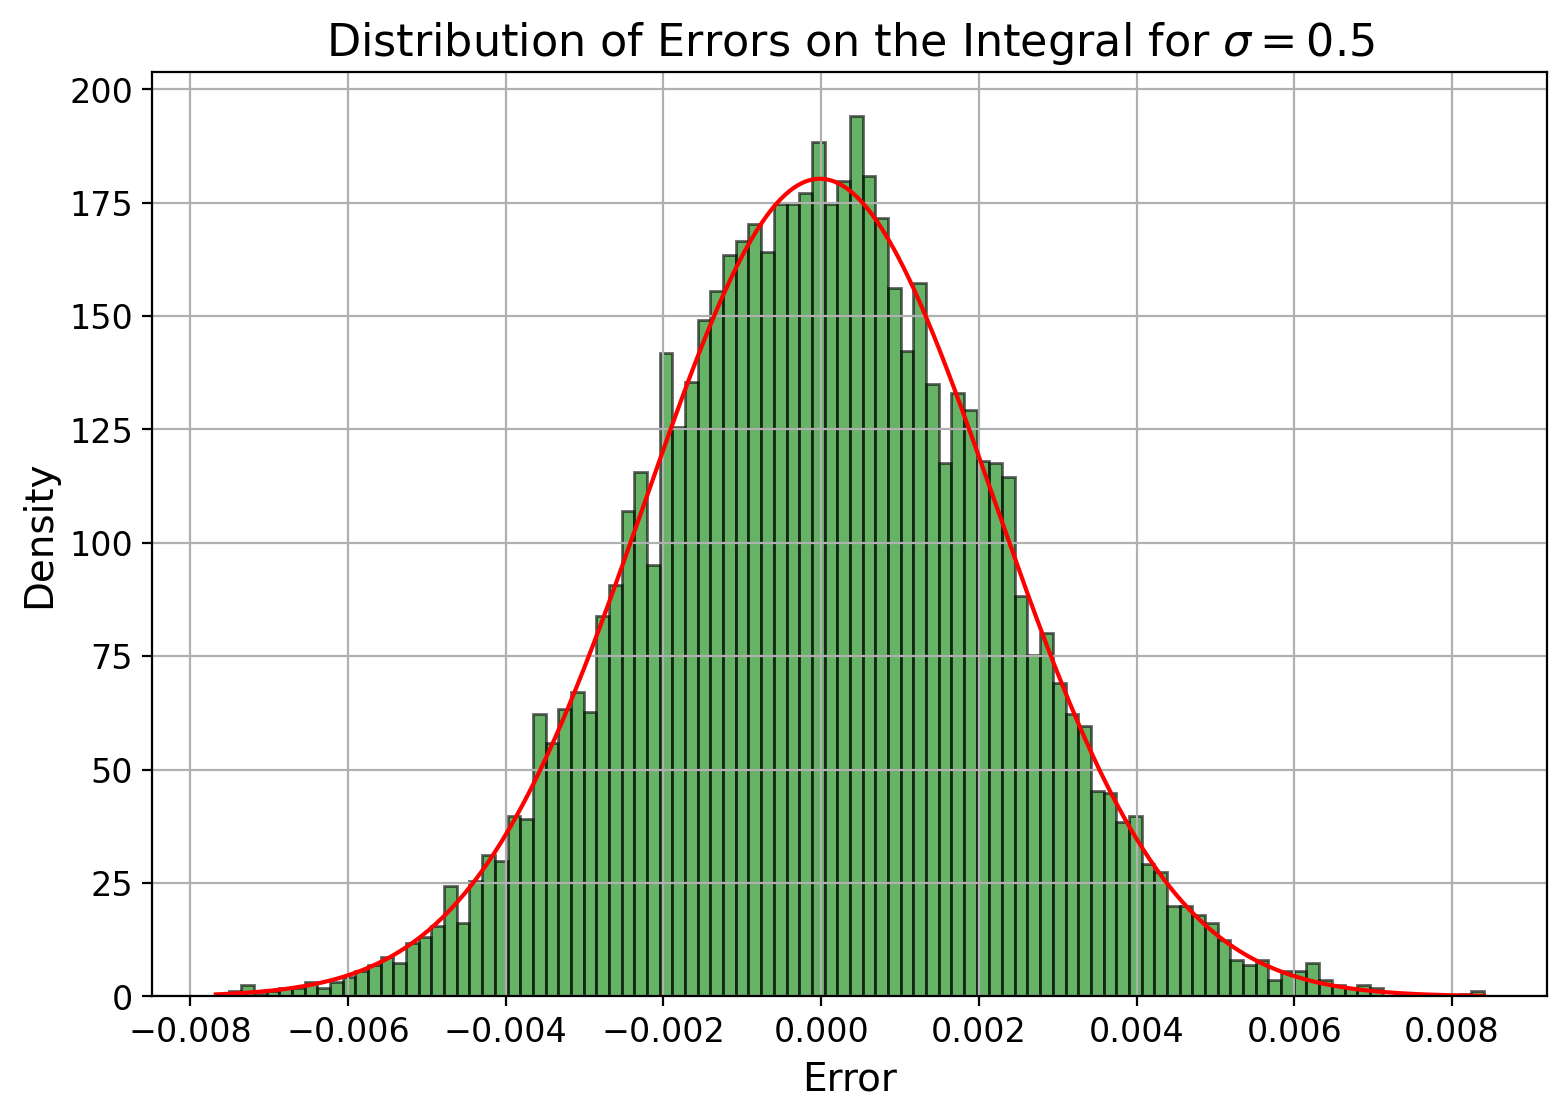

In [16]:
# We have 10000 realizations of the error for a fixed sigma, we plot the histrogram of these errors to see the distribution of the errors for a fixed sigma value. We expect this distribution to be approximately normal due to the Central Limit Theorem, since the error is the result of averaging many random samples.

# Compute mean and standard deviation of the error distribution
mean_error = np.mean(errors)
std_error = np.std(errors)

# Create a grid for plotting the Gaussian fit
xgrid = np.linspace(errors.min(), errors.max(), 1000)

# Print the parameters
print(f"Mean error: {mean_error:.6e}")
print(f"Std error: {std_error:.6e}")
print(f"Theoretical std (sigma^2/sqrt(N)): {(sigma**2) / np.sqrt(10000):.6e}")

# Create a Gaussian distribution with the computed parameters
gauss = norm(mean_error, std_error)

# Plot the distribution of errors
plt.figure(figsize=(9, 6))
plt.hist(errors, bins=100, density=True, alpha=0.6, color='g', edgecolor='black')
plt.plot(xgrid, gauss.pdf(xgrid), color='r', label='Fitted Gaussian')
plt.title(r'Distribution of Errors on the Integral for $\sigma = {}$'.format(sigma))
plt.xlabel('Error')
plt.ylabel('Density')
plt.grid()
plt.show()

**2. Kicking horses**

A famous early application of low-number statistics was an analysis of Prussian cavalryman horse-kick deaths by [Bortkiewicz](https://www.wikiwand.com/en/Ladislaus_Bortkiewicz) in 1898.

He studied the distribution of 122 men kicked to death by horses among 10 Prussian army corps within 20 years (so a total number of corps of 200). He recorded the number of corps with a given number of deaths:
[Data](https://www-jstor-org.proxy-ub.rug.nl/stable/1403193?seq=1)
| Number of deaths per corps per year | Number of corps |
| --- | --- |
| 0 | 109 |
| 1 | 65 |
| 2 | 22 |
| 3 | 3 |
| 4 | 1 |

- Plot the resulting probability distribution. Careful with the normalization
- How does it look like? Again try to fit it by hand.

(Hint: think about sample mean and sample variance)


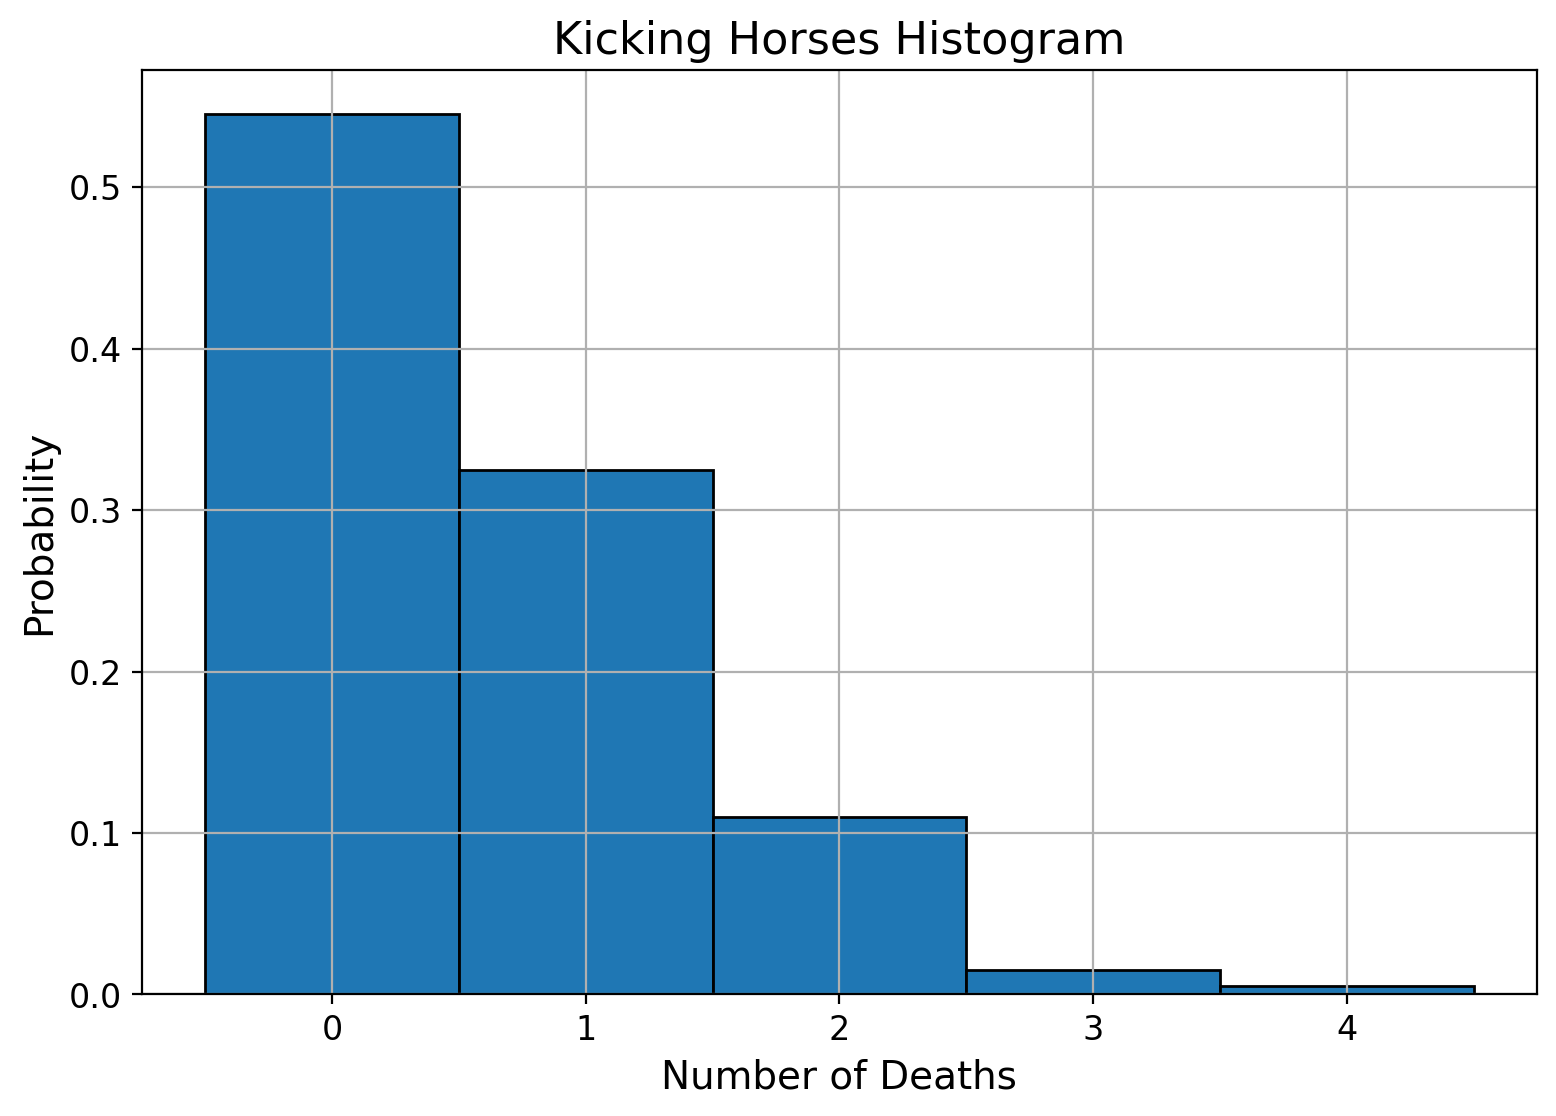

In [17]:
# Original data
KHprob = [(0,109),(1,65),(2,22),(3,3),(4,1)]

# Expand data into a list of deaths
deaths = []
for x, count in KHprob:
    deaths.extend([x] * count) # list of length count with each element equal to x
    # Ex. x=2, count=22 -> deaths.extend([2] * 22) -> adds 22 elements of value 2 to the list

# Plot histogram
plt.figure(figsize=(9, 6))
plt.hist(deaths, bins=np.arange(-0.5, 5.5, 1), edgecolor='black', density=True)
plt.title('Kicking Horses Histogram')
plt.xlabel('Number of Deaths')
plt.ylabel('Probability')
plt.grid()
plt.show()

MLE for lambda: 0.61


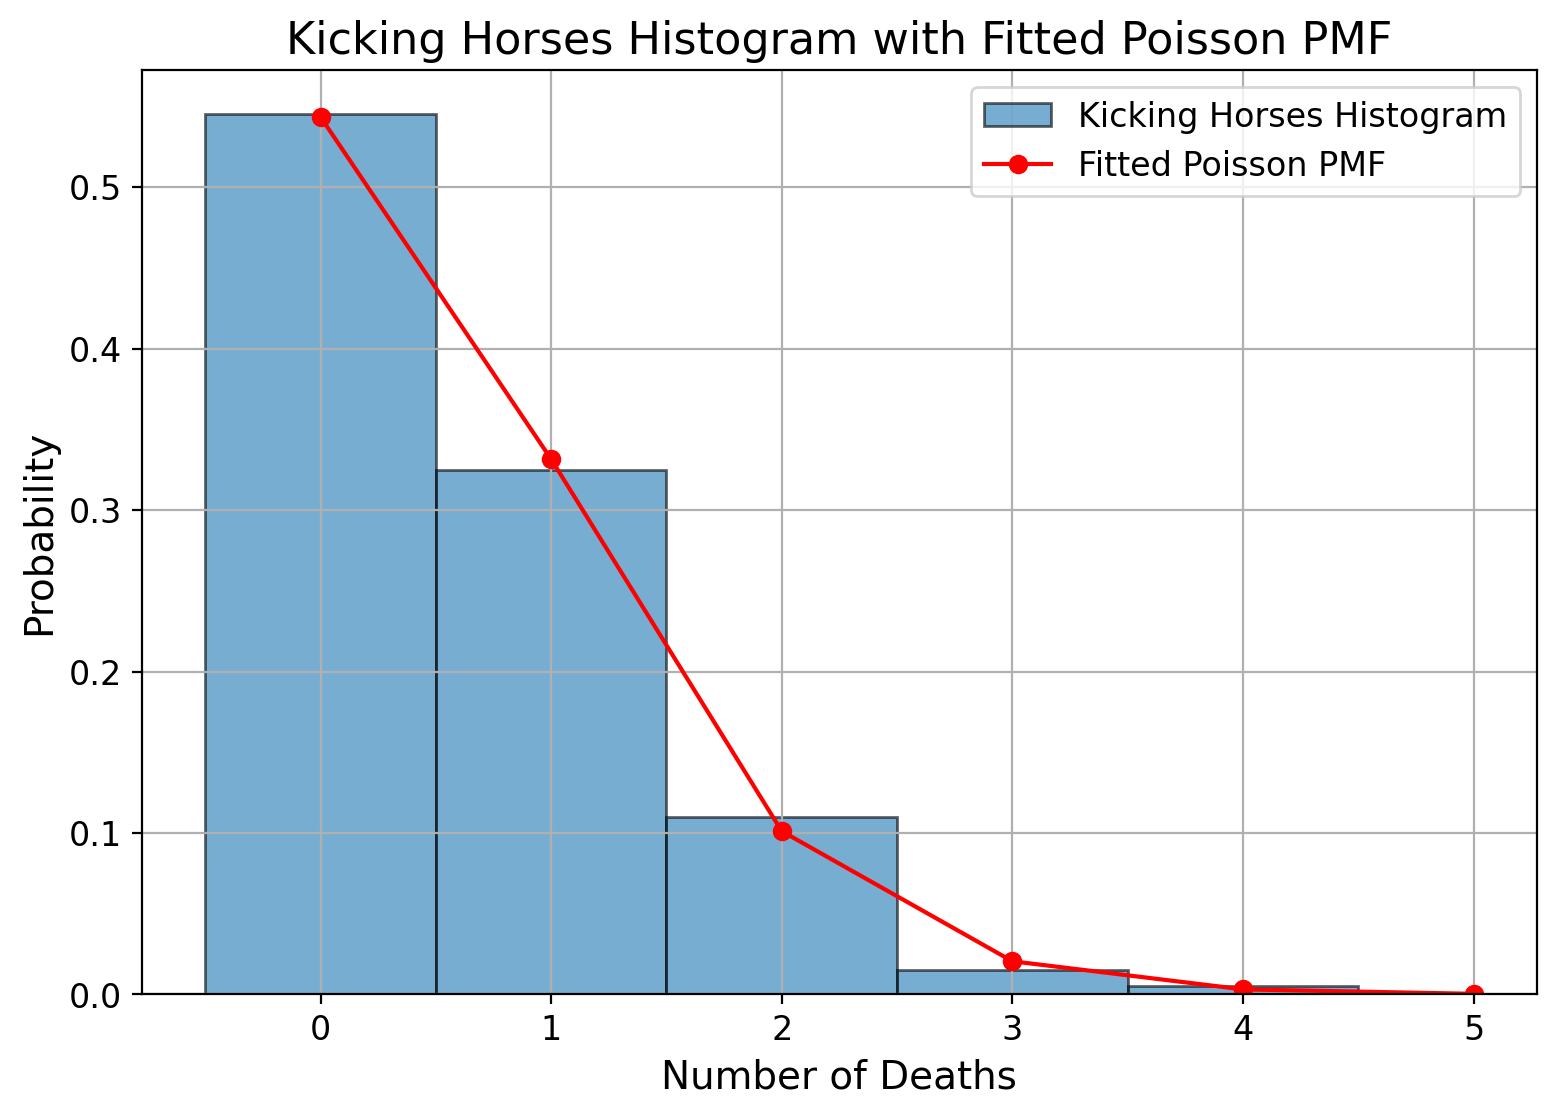

In [18]:
# Now let us fit a Poisson distribution to this data
# Convert deaths to a numpy array
deaths = np.array(deaths)

# Get the mean number of deaths (this is the MLE for lambda in a Poisson distribution)
lambda_mle = np.mean(deaths)
print(f'MLE for lambda: {lambda_mle}')

# Create a Poisson distribution with the estimated lambda
poisson_dist = poisson(mu=lambda_mle)

# Plot histogram of kicks
plt.figure(figsize=(9, 6))
plt.hist(deaths, bins=np.arange(-0.5, 5.5, 1), edgecolor='black', density=True, alpha=0.6, label='Kicking Horses Histogram')

# Plot the fitted Poisson PMF
x = np.arange(0, 6)
plt.plot(x, poisson_dist.pmf(x), 'ro-', label='Fitted Poisson PMF')
plt.title('Kicking Horses Histogram with Fitted Poisson PMF')
plt.xlabel('Number of Deaths')
plt.ylabel('Probability')
plt.legend()
plt.grid()
plt.show()